    price  squarefeet  bedrooms  bathrooms brick neighborhood
0  571500        1790         2          2    No         East
1  571000        2030         4          2    No         East
2  574000        1740         3          2    No         East
3  473500        1980         3          2    No         East
4  599000        2130         3          3    No         East
<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   price         128 non-null    int64
 1   squarefeet    128 non-null    int64
 2   bedrooms      128 non-null    int64
 3   bathrooms     128 non-null    int64
 4   brick         128 non-null    str  
 5   neighborhood  128 non-null    str  
dtypes: int64(4), str(2)
memory usage: 7.0 KB
None

Cluster counts:
Cluster
1    69
0    35
2    24
Name: count, dtype: int64


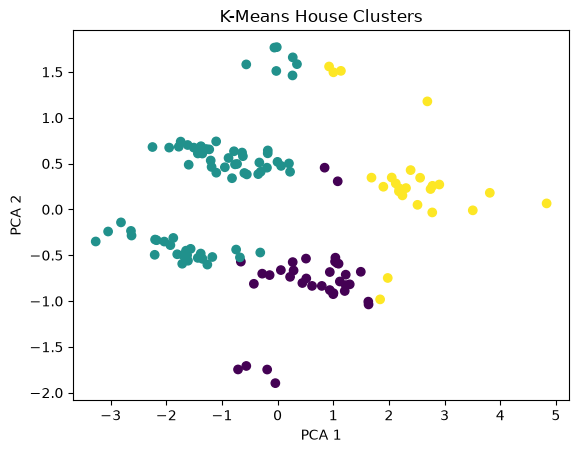


NLP clusters:
NLP_Cluster
0    86
1    42
Name: count, dtype: int64

Done! File saved as houseprices_result.csv


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_4985/96735680.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [1]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# 2. Load dataset
df = pd.read_csv("houseprices.csv")
print(df.head())
print(df.info())

# 3. K-Means on numerical columns
num = df.select_dtypes(include="number").dropna(axis=1)

X = StandardScaler().fit_transform(num)

# 4. K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

print("\nCluster counts:")
print(df["Cluster"].value_counts())

# 5. Visualize clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means House Clusters")
plt.show()

# 6. NLP - find a text column
text_cols = df.select_dtypes(include="object").columns

if len(text_cols) > 0:
    text_col = text_cols[0]
    
    text = df[text_col].fillna("").astype(str)
    
    # TF-IDF
    tfidf = TfidfVectorizer(stop_words="english", max_features=500)
    X_text = tfidf.fit_transform(text)

    # NLP K-Means
    nlp_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df["NLP_Cluster"] = nlp_kmeans.fit_predict(X_text)

    print("\nNLP clusters:")
    print(df["NLP_Cluster"].value_counts())

# 7. Save result
df.to_csv("houseprices_result.csv", index=False)

print("\nDone! File saved as houseprices_result.csv")